**TITANIC COMPETITION FOR MACHINE LEARNING **

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

# Any results you write to the current directory are saved as output.

['train.csv', 'gender_submission.csv', 'test.csv']


Importing the data sets:

In [2]:
d_train = pd.read_csv('../input/train.csv')
d_test = pd.read_csv('../input/test.csv')

In [3]:
d_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.6+ KB


In [4]:
d_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
d_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Name           418 non-null object
Sex            418 non-null object
Age            332 non-null float64
SibSp          418 non-null int64
Parch          418 non-null int64
Ticket         418 non-null object
Fare           417 non-null float64
Cabin          91 non-null object
Embarked       418 non-null object
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [6]:
d_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


**Cleaning data:**

Excluding unnecessary columns.

In [7]:
d_train.drop(['Name', 'Ticket', 'Cabin', 'Embarked'], axis=1, inplace=True)
d_test.drop(['Name', 'Ticket', 'Cabin', 'Embarked'], axis=1, inplace=True)

Changing onject classed features to integers:

In [8]:
# Change male to 1 and female to 0:
d_train.Sex = [1 if each =='male' else 0 for each in d_train.Sex]
d_test.Sex = [1 if each =='male' else 0 for each in d_test.Sex]

In [9]:
d_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Sex            891 non-null int64
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Fare           891 non-null float64
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


There are NaN values in d_train.Age column.

In [10]:
d_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Sex            418 non-null int64
Age            332 non-null float64
SibSp          418 non-null int64
Parch          418 non-null int64
Fare           417 non-null float64
dtypes: float64(2), int64(5)
memory usage: 22.9 KB


There are NaN values in the d_test Age and Fare columns.

So I will fill the NaN values with mean values of the Age and Fare columns.

In [11]:
# Lets see the mean values of Age columns:
print('Mean value of train data set Age column is: ', np.mean(d_train.Age))
print('Mean value of test data set Age column is: ', np.mean(d_test.Age))

Mean value of train data set Age column is:  29.69911764705882
Mean value of test data set Age column is:  30.272590361445783


In [12]:
d_train['Age'].fillna(d_train['Age'].mean(), inplace=True)
d_test['Age'].fillna(d_test['Age'].mean(), inplace=True)
d_test['Fare'].fillna(d_test['Fare'].mean(), inplace=True)

In [13]:
d_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,1,22.0,1,0,7.2500
1,2,1,1,0,38.0,1,0,71.2833
2,3,1,3,0,26.0,0,0,7.9250
3,4,1,1,0,35.0,1,0,53.1000
4,5,0,3,1,35.0,0,0,8.0500


See how many passengers survived and how many couldn't:

0    549
1    342
Name: Survived, dtype: int64

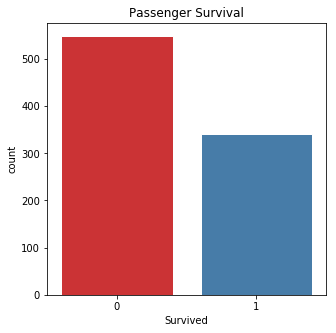

In [14]:
plt.figure(figsize=[5,5])
plt.title('Passenger Survival')
sns.set(style='darkgrid')
ax = sns.countplot(x= 'Survived', data=d_train, palette='Set1')
d_train.loc[:,'Survived'].value_counts()

Let's see our training data sets statistics:

In [15]:
d_train.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.647587,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,0.477990,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,1.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
d_train.corr()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.042939,0.033207,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.543351,-0.069809,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,0.131900,-0.331339,0.083081,0.018443,-0.549500
Sex,0.042939,-0.543351,0.131900,1.000000,0.084153,-0.114631,-0.245489,-0.182333
Age,0.033207,-0.069809,-0.331339,0.084153,1.000000,-0.232625,-0.179191,0.091566
SibSp,-0.057527,-0.035322,0.083081,-0.114631,-0.232625,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.245489,-0.179191,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,-0.182333,0.091566,0.159651,0.216225,1.000000


**MACHINE LEARNING MODEL**

**Separeting x and y Features:**

In [17]:
# True values:
y = d_train.Survived
# Features will be used for predictions:
x = d_train.drop(['Survived'], axis=1)

**1. Random Forest Algorithm:**

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Defining model:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Training Model:
rf.fit(x, y)

# Predicting test data set using trained model:
y_pred = rf.predict(d_test)

len(y_pred)

418

Combine our predictions and test data set for the submission csv:

In [19]:
d_subm_rf = pd.DataFrame({'PassengerId': d_test['PassengerId'], 'Survived': y_pred})

Exporting dataframe to csv file:

In [20]:
d_subm_rf.to_csv('data_submission.csv', index = False)

**2. Naive Bayes Algorithm:**

In [21]:
from sklearn.naive_bayes import GaussianNB

# Defining NB model:
nb = GaussianNB()

# Training the model:
nb.fit(x,y)

# Predicting d_test:
y_pred_nb = nb.predict(d_test)

Combine our predictions and test data set for the submission csv:

In [22]:
d_subm_nb = pd.DataFrame({'PassengerId': d_test['PassengerId'], 'Survived': y_pred_nb})

Exporting dataframe to csv file:

In [23]:
d_subm_nb.to_csv('data_submission_nb.csv', index = False)

**3. Logistic Regression Algorithm:**

In [24]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(x,y)

y_pred_lr = lr.predict(d_test)

/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


In [25]:
d_subm_lr = pd.DataFrame({'PassengerId': d_test['PassengerId'], 'Survived': y_pred_lr})

In [26]:
d_subm_lr.to_csv('data_submission_lr.csv', index = False)